## Read files

In [1]:
import pandas as pd
import numpy as np
import os

work_folder = '/home/dhuang/work/Ig-fold/nanobody_db/connector_correlation/'
os.chdir(work_folder)

Duplicated cluster data (95%)

In [12]:

target_list_path = os.path.join(work_folder, 'dupl_INDI_cluster95_rep.tsv')
target_list_df = pd.read_csv(target_list_path, sep='\t')

connector_generation_folder = os.path.join(work_folder, 'batch_graft_dupl_INDI_rep95_1s_top100_all_connector_250623/')

All duplicated data

In [2]:

target_list_path = os.path.join(work_folder, 'dupl_INDI_passed.tsv')
target_list_df = pd.read_csv(target_list_path, sep='\t')

# connector_generation_folder = os.path.join(work_folder, 'batch_graft_dupl_INDI_passed_1s_top25_all_connector_250620/')
connector_generation_folder = os.path.join(work_folder, 'batch_graft_dupl_INDI_passed_1s_top100_all_connector_250701/')

### Original structure + structure similarity + sequence similarity

Bit score；对 raw 进行长度和统计校正后得分，越大表明匹配越可靠

nident	完全相同氨基酸个数

In [3]:
def read_generations(target_list_df, generation_folder):
    # 初始化空列表来存储每次循环生成的 DataFrame
    all_results = []
    success = fail = 0

    region_list = ['all', 'connector1', 'connector2', 'connector3']
    # embe_list = ['raw_embeddings', 'pre_q_embeddings', 'q_embeddings', 'ca_distance']
    embe_list = ['raw_embeddings', 'pre_q_embeddings', 'ca_distance']

    for pdb_id in target_list_df['pdb_id']: 
        pdb_folder = os.path.join(generation_folder, pdb_id)
        
        # 读取 all_generation.tsv
        target = 'all'   # passed or selected
        file_name = 'all' if target == 'full' else target
        generation_tsv = os.path.join(pdb_folder, f'temp_generation/{target}_info/{file_name}_generation.tsv')

        # 如果文件不存在，则警告并跳过
        if not os.path.exists(generation_tsv):
            print(f"[WARNING] Skipped {pdb_id}: {generation_tsv} do not exist")
            fail += 1
            continue

        generation_df = pd.read_csv(generation_tsv, sep='\t')

        try:
            # 读取Distance file
            for region in region_list:
                for embe in embe_list:
                    # NOTE be careful for filename formate
                    original_distance_file_path = os.path.join(pdb_folder, 'similarity', f'{embe}_similarity_{region}.tsv')
                    # generated_distance_file_path = os.path.join(pdb_folder, 'generation_tokenized_structure', f'{embe}_distance_{region}.tsv') 
                    generated_distance_file_path = os.path.join(pdb_folder, 'generation_tokenized_structure', f'{embe}_similarity_{region}.tsv') # Lastest          
                    
                    original_distance_df = pd.read_csv(original_distance_file_path, sep='\t').rename(
                        columns={'euclidean': f'original_euclidean_{region}_{embe}', 'cosine': f'original_cosine_{region}_{embe}'}
                    )
                    generated_distance_df = pd.read_csv(generated_distance_file_path, sep='\t').rename(
                        columns={'euclidean': f'grafted_euclidean_{region}_{embe}', 'cosine': f'grafted_cosine_{region}_{embe}'}
                    )
                    
                    generation_df = generation_df.merge(original_distance_df, how='inner', left_on='PDB_ID', right_on='pdb_id')
                    generation_df = generation_df.drop(columns=['pdb_id'])
                    
                    # NOTE merged with 'Filename' !!!
                    generation_df['pdb_id_stripped'] = (generation_df['Filename'].str.replace(r'\.pdb$', '', regex=True))

                    generation_df = pd.merge(
                        generation_df,
                        generated_distance_df,
                        how='inner',
                        left_on='pdb_id_stripped',
                        right_on='pdb_id'
                    )

                    generation_df = generation_df.drop(columns=['pdb_id_stripped', 'pdb_id'])
                    
            # 读取Foldseek输出文件
            foldseek_tsv = os.path.join(os.path.join(pdb_folder, 'similarity'), f'{pdb_id}_foldseek_output.tsv')
            foldseek_df = pd.read_csv(foldseek_tsv, sep='\t').rename(
                columns={'bits': 'structure_bits', 'nident': 'structure_nident'}
            )
            query_len = len(foldseek_df.iloc[0]['tseq'])    # Since the query include in database, the most similar row (first row) was itself
            # 新增 qident = structure_nident / query_len，保留三位小数
            foldseek_df['structure_qident'] = np.sqrt(foldseek_df['structure_nident'] / query_len).round(3)
            foldseek_df['target'] = foldseek_df['target'].replace('.pdb', '')    # Sometime the result has additional '.pdb'

            # MMSeqs2 result - Sequence identical
            mmseqs_tsv = os.path.join(os.path.join(pdb_folder, 'similarity'), f'{pdb_id}_mmseqs_output.tsv')
            mmseqs_df = pd.read_csv(mmseqs_tsv, sep='\t').rename(
                columns={'bits': f'sequence_bits', 'nident': 'sequence_nident'}
            )
            query_len = len(foldseek_df.iloc[0]['tseq'])    # Since the query include in database, the most similar row (first row) was itself
            # 新增 qident = structure_nident / query_len，保留三位小数
            mmseqs_df['sequence_qident'] = np.sqrt(mmseqs_df['sequence_nident'] / query_len).round(3)
            mmseqs_df['target'] = mmseqs_df['target'].replace('.pdb', '')    # Sometime the result has additional '.pdb'

            # Use 'bits' to compare the difference between structure and sequence contribution
            # Add foldseek 'bits' info
            full_merged_df = pd.merge(
                generation_df, 
                foldseek_df[['target', 'structure_qident', 'structure_bits', 'qtmscore']], 
                how='inner', 
                left_on='PDB_ID', 
                right_on='target'
            )
            full_merged_df = full_merged_df.drop(columns=['target'])

            # Add mmseqs 'bits' info
            full_merged_df = pd.merge(
                full_merged_df, 
                mmseqs_df[['target', 'sequence_qident', 'sequence_bits']], 
                how='inner', 
                left_on='PDB_ID', 
                right_on='target'
            )
            full_merged_df = full_merged_df.drop(columns=['target'])

            # Rename - add query pdb_id
            full_merged_df['PDB_ID'] = full_merged_df['PDB_ID'].apply(lambda x: f"{pdb_id}_{x}")
        
        except Exception as e:
            print(f"[ERROR] extract {pdb_id} fail: {e}")
            full_merged_df = None
            fail += 1
        
        # 将结果存储到列表中
        if full_merged_df is not None:
            all_results.append(full_merged_df)
            success += 1

    # 将所有结果行叠加
    final_df = pd.concat(all_results, ignore_index=True)

    print(f"Passed files: {success}\t Failed files: {fail}")

    return final_df


In [4]:
connector_df = read_generations(target_list_df=target_list_df, generation_folder=connector_generation_folder)

# When using s1, no replication
dupl_connector_df = connector_df.drop_duplicates(subset=['PDB_ID'], keep='first')


[WARNING] Skipped 8jbhE: /home/dhuang/work/Ig-fold/nanobody_db/connector_correlation/batch_graft_dupl_INDI_passed_1s_top100_all_connector_250701/8jbhE/temp_generation/all_info/all_generation.tsv do not exist
[WARNING] Skipped 7pklL: /home/dhuang/work/Ig-fold/nanobody_db/connector_correlation/batch_graft_dupl_INDI_passed_1s_top100_all_connector_250701/7pklL/temp_generation/all_info/all_generation.tsv do not exist
Passed files: 841	 Failed files: 2


## cRMSD and pTM

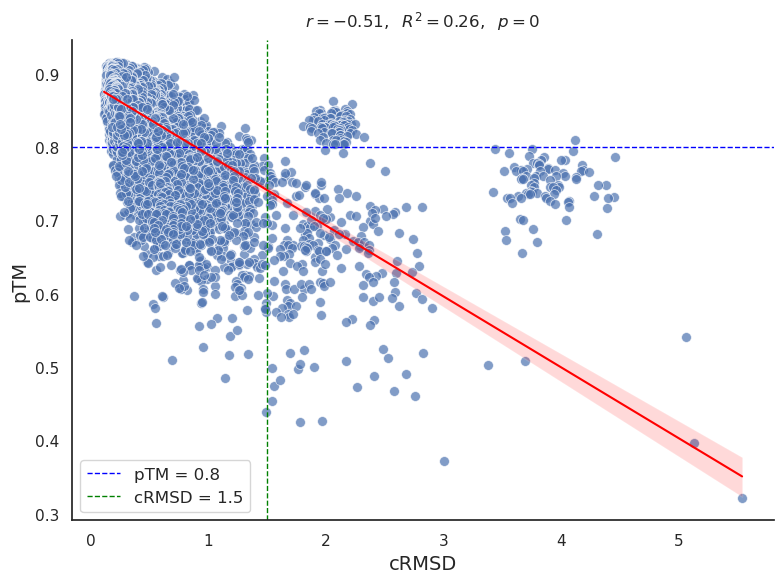

In [5]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr

# 准备数据
x = connector_df['cRMSD']
y = connector_df['pTM']

# 1) 计算 Pearson r、p-value 和 R²
r, p_val = spearmanr(x, y)
r2 = r**2

# 2) 绘图
sns.set(style="white")
fig, ax = plt.subplots(figsize=(8,6))

# 2.1 散点
sns.scatterplot(x=x, y=y, s=50, alpha=0.7, ax=ax)

# 2.2 回归线
sns.regplot(
    x=x, y=y,
    scatter=False,
    ci=95,
    line_kws={'color':'red','lw':1.5},
    ax=ax
)

# 2.3 虚线：pTM=0.8 和 cRMSD=1.5
ax.axhline(0.8, color='blue',  linestyle='--', lw=1, label='pTM = 0.8')
ax.axvline(1.5, color='green', linestyle='--', lw=1, label='cRMSD = 1.5')

# 3) 注释 r、R2 和 p-value
# ax.text(
#     0.9, 0.9,
#     f'$r = {r:.3f}$\n$R^2 = {r2:.3f}$\n$p = {p_val:.3g}$',
#     transform=ax.transAxes,
#     fontsize=12,
#     verticalalignment='top',
#     bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
# )
title_str = (
    f"$r={r:.2f},\\ \\;R^2={r2:.2f},\\ \\;p={p_val:.2g}$"
)

# 1) 使用 Axes 级标题，右对齐
ax.set_title(
    title_str,
    loc='center',            # 'left' / 'center' / 'right'
    fontsize=12,
    pad=10,                 # 标题与绘图区的距离
    fontstyle='italic'      # 可选：斜体、加粗等
)

# 4) 轴标签、标题
ax.set_xlabel('cRMSD', fontsize=14)
ax.set_ylabel('pTM',   fontsize=14)
# ax.set_title('Scatter: cRMSD vs. pTM', fontsize=16)

# 5) 图例
ax.legend(loc='lower left', fontsize=12)

# 6) 美化
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


## Correlation

In [6]:
from scipy.stats import pearsonr
from scipy.stats import spearmanr

### Global

In [7]:
print('structure_qident vs. cRMSD:')
correlation, p_value = pearsonr(connector_df['structure_qident'], connector_df['cRMSD'])
print(f"Pearson: {correlation}, P-value: {p_value}")
# print('structure_qtmscore vs. cRMSD:')
# correlation, p_value = pearsonr(connector_df['qtmscore'], connector_df['cRMSD'])
# print(f"Pearson: {correlation}, P-value: {p_value}")
print()
print('sequence_qident vs. cRMSD:')
correlation, p_value = pearsonr(connector_df['sequence_qident'], connector_df['cRMSD'])
print(f"Pearson: {correlation}, P-value: {p_value}")
print()

print('structure_qident vs. pTM:')
correlation, p_value = pearsonr(connector_df['structure_qident'], connector_df['pTM'])
print(f"Pearson: {correlation}, P-value: {p_value}")
# print('foldseek_qtmscore vs. pTM:')
# correlation, p_value = pearsonr(connector_df['qtmscore'], connector_df['pTM'])
# print(f"Pearson: {correlation}, P-value: {p_value}")
print()
print('sequence_qident vs. pTM:')
correlation, p_value = pearsonr(connector_df['sequence_qident'], connector_df['pTM'])
print(f"Pearson: {correlation}, P-value: {p_value}")

structure_qident vs. cRMSD:
Pearson: -0.02348658007411973, P-value: 1.208275639958877e-10

sequence_qident vs. cRMSD:
Pearson: -0.014772394898346843, P-value: 5.140084600950499e-05

structure_qident vs. pTM:
Pearson: 0.07140384151677277, P-value: 1.6731324941040086e-85

sequence_qident vs. pTM:
Pearson: 0.06285608138711646, P-value: 1.2163011387271634e-66


In [8]:
print('structure_bits vs. cRMSD:')
correlation, p_value = pearsonr(connector_df['structure_bits'], connector_df['cRMSD'])
print(f"Pearson: {correlation}, P-value: {p_value}")
# print('structure_qtmscore vs. cRMSD:')
# correlation, p_value = pearsonr(connector_df['qtmscore'], connector_df['cRMSD'])
# print(f"Pearson: {correlation}, P-value: {p_value}")
print()
print('sequence_bits vs. cRMSD:')
correlation, p_value = pearsonr(connector_df['sequence_bits'], connector_df['cRMSD'])
print(f"Pearson: {correlation}, P-value: {p_value}")
print()

print('structure_bits vs. pTM:')
correlation, p_value = pearsonr(connector_df['structure_bits'], connector_df['pTM'])
print(f"Pearson: {correlation}, P-value: {p_value}")
# print('foldseek_qtmscore vs. pTM:')
# correlation, p_value = pearsonr(connector_df['qtmscore'], connector_df['pTM'])
# print(f"Pearson: {correlation}, P-value: {p_value}")
print()
print('sequence_bits vs. pTM:')
correlation, p_value = pearsonr(connector_df['sequence_bits'], connector_df['pTM'])
print(f"Pearson: {correlation}, P-value: {p_value}")

structure_bits vs. cRMSD:
Pearson: -0.3850116647572525, P-value: 0.0

sequence_bits vs. cRMSD:
Pearson: -0.07880276080486626, P-value: 8.869246664904408e-104

structure_bits vs. pTM:
Pearson: 0.47490353268345104, P-value: 0.0

sequence_bits vs. pTM:
Pearson: 0.0921378743028311, P-value: 2.6228683244363505e-141


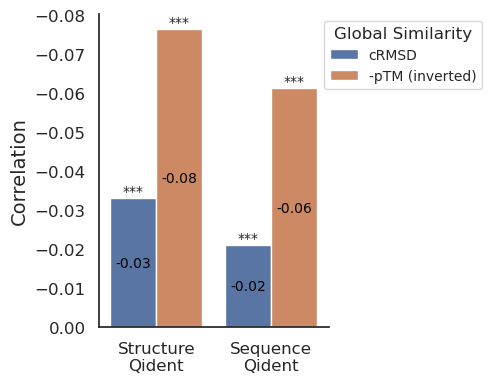

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.container import BarContainer

# 1. 构造汇总结果，pTM 取反
labels = ['structure_qident', 'sequence_qident']
targets = ['cRMSD', 'pTM']

rows = []
for lab in labels:
    for tgt in targets:
        corr, pval = spearmanr(connector_df[lab], connector_df[tgt])
        # 对 pTM 取反
        if tgt == 'pTM':
            corr = -corr
        rows.append({
            'label': lab,
            'correlation': corr,
            'p_value':    pval,
            'source':     tgt
        })
res_df = pd.DataFrame(rows)

# 2. 可读 xticks
xticks = ['Structure\nQident', 'Sequence\nQident']

# 3. 画图
sns.set(style="white")
fig, ax = plt.subplots(figsize=(5, 4))

palette = {
    'cRMSD': sns.color_palette("deep")[0],
    'pTM':   sns.color_palette("deep")[1]
}

sns.barplot(
    data=res_df,
    x='label', y='correlation',
    hue='source',
    palette=palette,
    dodge=True,
    ax=ax
)

# 4. 设置 x 轴
ax.set_xticks(range(len(xticks)))
ax.set_xticklabels(xticks, rotation=0, ha='center', fontsize=12)

# 5. 贴 r 值
for container in ax.containers:
    if isinstance(container, BarContainer):
        heights = [patch.get_height() for patch in container]
        labels  = [f"{h:.2f}" for h in heights]
        ax.bar_label(
            container,
            labels=labels,
            label_type='center',   # ← 中心贴
            padding=0,             # 贴得更紧凑
            fontsize=10,
            color='black'          # 也可以选个对比色，比如白色
        )

# 6. p-value 星号
def p_to_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

for bar, p in zip(ax.patches, res_df['p_value']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        p_to_stars(p),
        ha='center', va='bottom',
        fontsize=10
    )

# 7. 美化 & 注释 pTM 已取负
ax.set_xlabel('')
ax.set_ylabel('Correlation', fontsize=14)
ax.tick_params(axis='y', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 修改图例标签：将 'pTM' 显示为 '-pTM'
leg = ax.legend(title='Global Similarity', loc='upper left', bbox_to_anchor=(0.95, 1), fontsize=10)
for text in leg.get_texts():
    if text.get_text() == 'pTM':
        text.set_text('-pTM (inverted)')
leg.get_title().set_text('Global Similarity')

ax.invert_yaxis()
plt.tight_layout()
plt.show()


## Connector

In [10]:
region_list = ['all', 'connector1', 'connector2', 'connector3']
embe_list = ['raw_embeddings', 'pre_q_embeddings', 'ca_distance']
stage_list = ['original', 'grafted']

## Normalized

In [11]:
from scipy.stats import boxcox


# Normalize based on length (connector: 4) and sqrt
for stage in stage_list:
    for region in region_list:
        for embe in embe_list:
            length = 12 if region == 'all' else 4
            col = f'{stage}_euclidean_{region}_{embe}'
            # print(f"{region} length = {length}")
            connector_df[f'{col}_norm'] = connector_df[col] / np.sqrt(length)

            # connector_df[f'{col}_norm'] = np.log(connector_df[f'{col}_norm'] + 1)

            # connector_df[f'{col}_norm'], fitted_lambda = boxcox(connector_df[f'{col}_norm'])
            # print(f"Optimal λ = {fitted_lambda:.3f}")

# Calculate change
for embe in embe_list:
    connector_df[f'change_euclidean_all_{embe}'] = abs(connector_df[f'original_euclidean_all_{embe}_norm'] - connector_df[f'grafted_euclidean_all_{embe}_norm'])

### Change

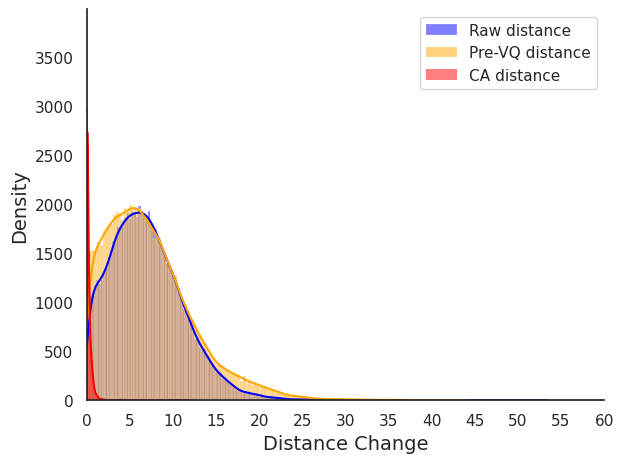

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(connector_df['change_euclidean_all_raw_embeddings'],
             kde=True, label='Raw distance', color='blue')
sns.histplot(connector_df['change_euclidean_all_pre_q_embeddings'],
             kde=True, label='Pre-VQ distance', color='orange')
sns.histplot(connector_df['change_euclidean_all_ca_distance'],
             kde=True, label='CA distance', color='red')

plt.legend()
plt.xlabel('Distance Change', fontsize=14)
plt.ylabel('Density',                 fontsize=14)

# 设置 x 轴间距为 0.5
xmin, xmax = plt.xlim()
plt.xticks(np.arange(0, np.ceil(xmax) + 5, 5))
plt.xlim(left=0)

# Seaborn 自动帮你去除上右边框
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()


“距离”这个变量只能 ≥0，导致标准化后也有下界

因此，一旦你的样本中没有比 0 更小的值，标准化后也不可能有无限延伸的左侧尾巴，左端必然在 
−𝜇/𝜎处“戛然而止”。

Skewness = 9.065
严重偏态
Normaltest p-value = 0
拒绝正态分布假设


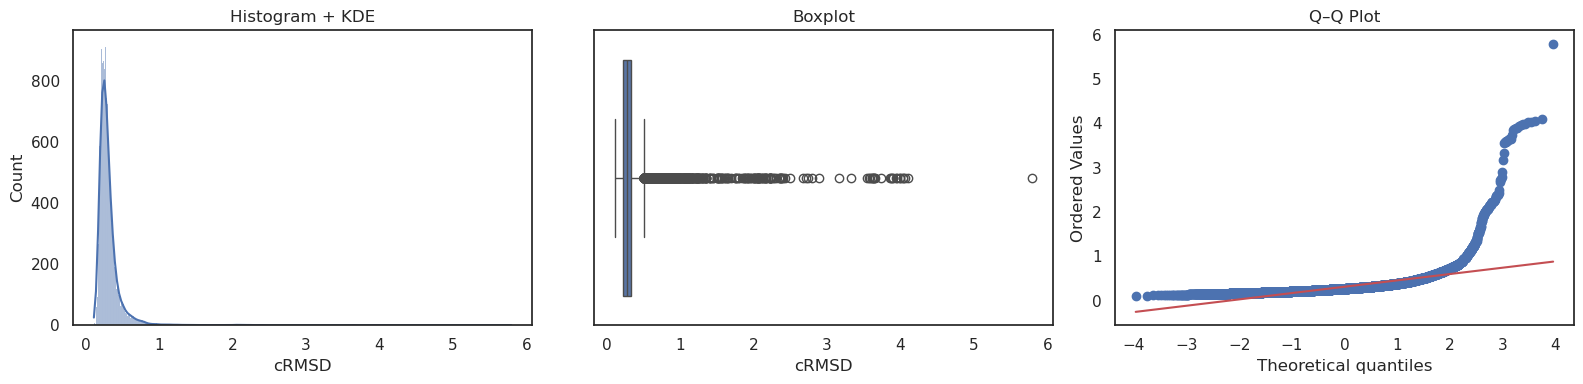

Skewness = 9.065
严重偏态
Normaltest p-value = 0
拒绝正态分布假设


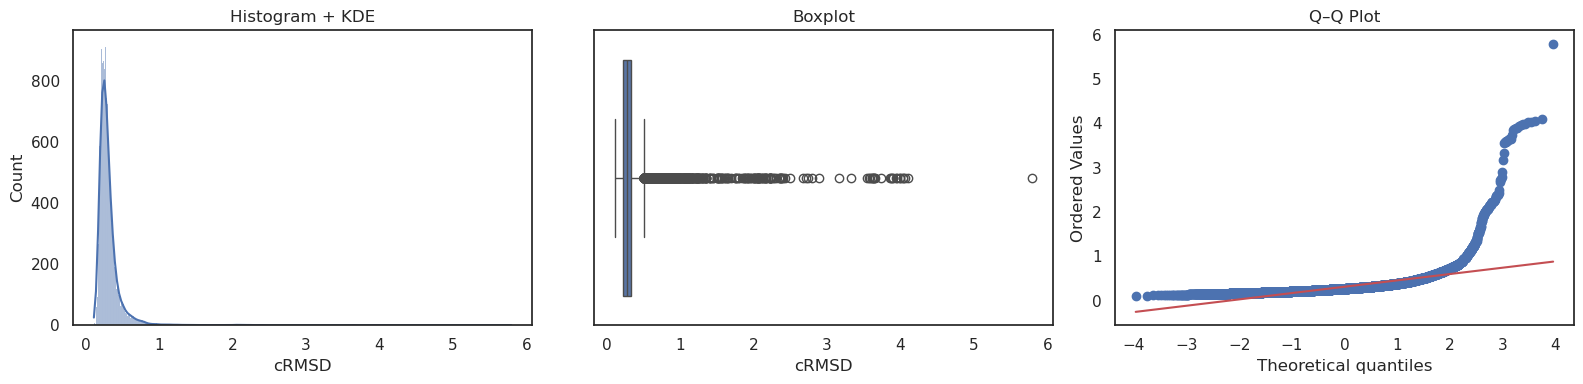

Skewness = 9.065
严重偏态
Normaltest p-value = 0
拒绝正态分布假设


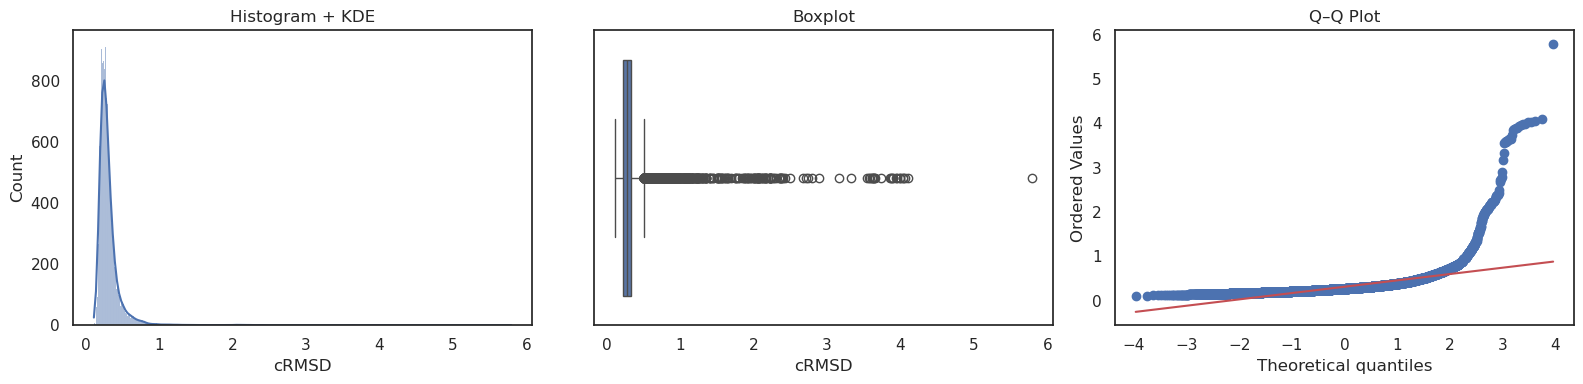

Skewness = 9.065
严重偏态
Normaltest p-value = 0
拒绝正态分布假设


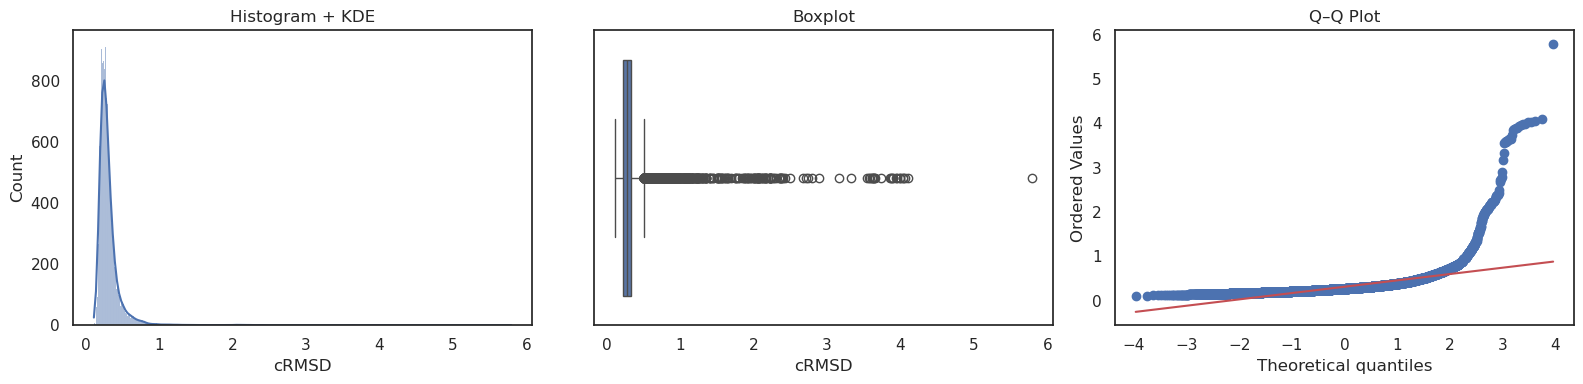

Skewness = 9.065
严重偏态
Normaltest p-value = 0
拒绝正态分布假设


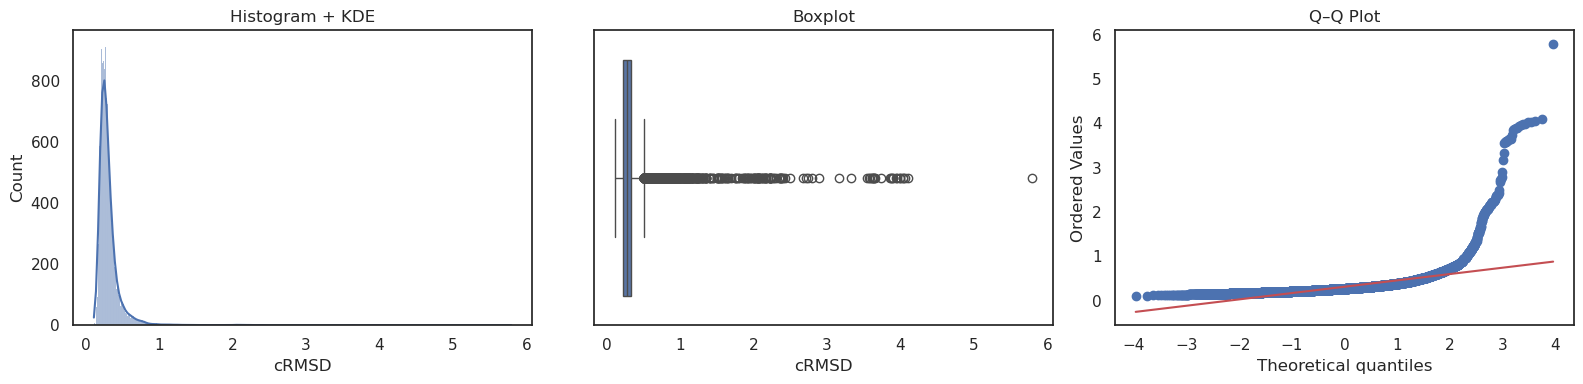

Skewness = 9.065
严重偏态
Normaltest p-value = 0
拒绝正态分布假设


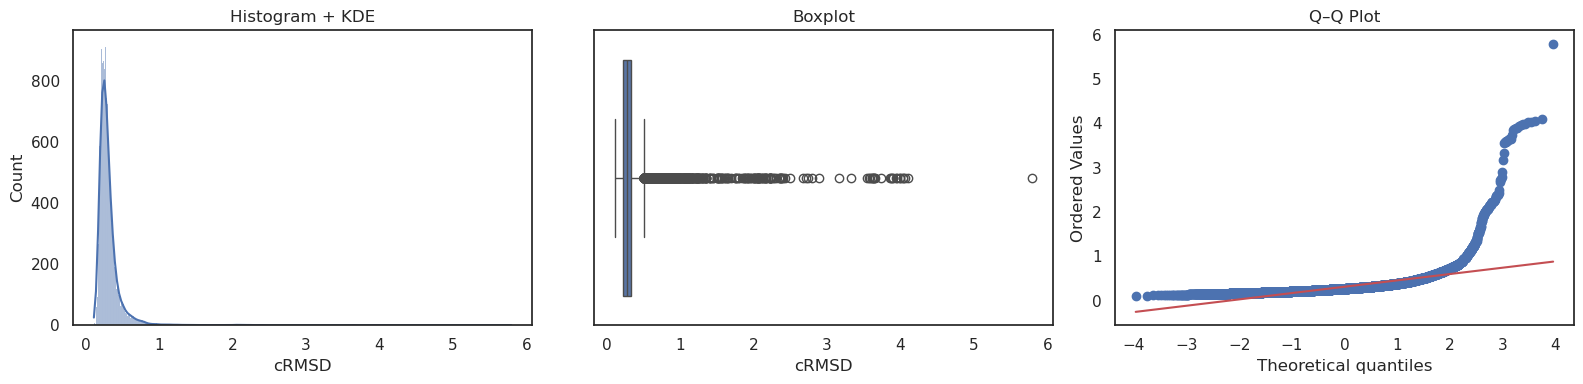

Skewness = 9.065
严重偏态
Normaltest p-value = 0
拒绝正态分布假设


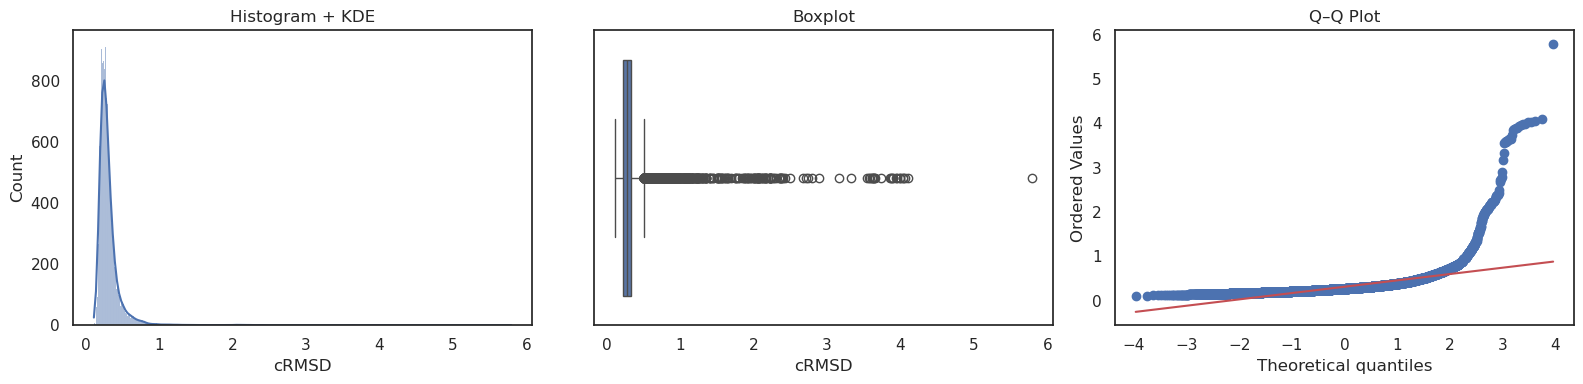

Skewness = 9.065
严重偏态
Normaltest p-value = 0
拒绝正态分布假设


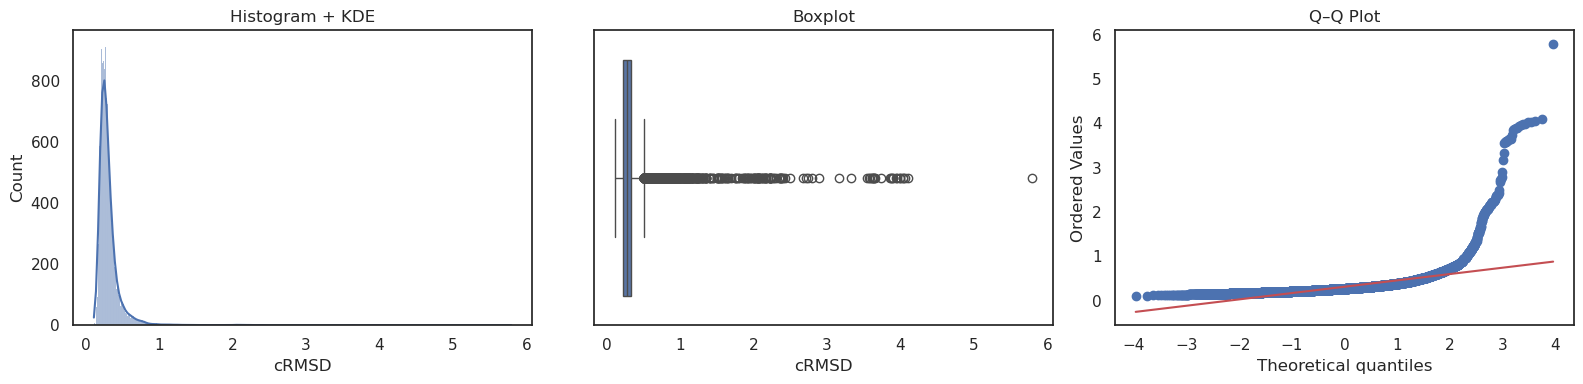

Skewness = 9.065
严重偏态
Normaltest p-value = 0
拒绝正态分布假设


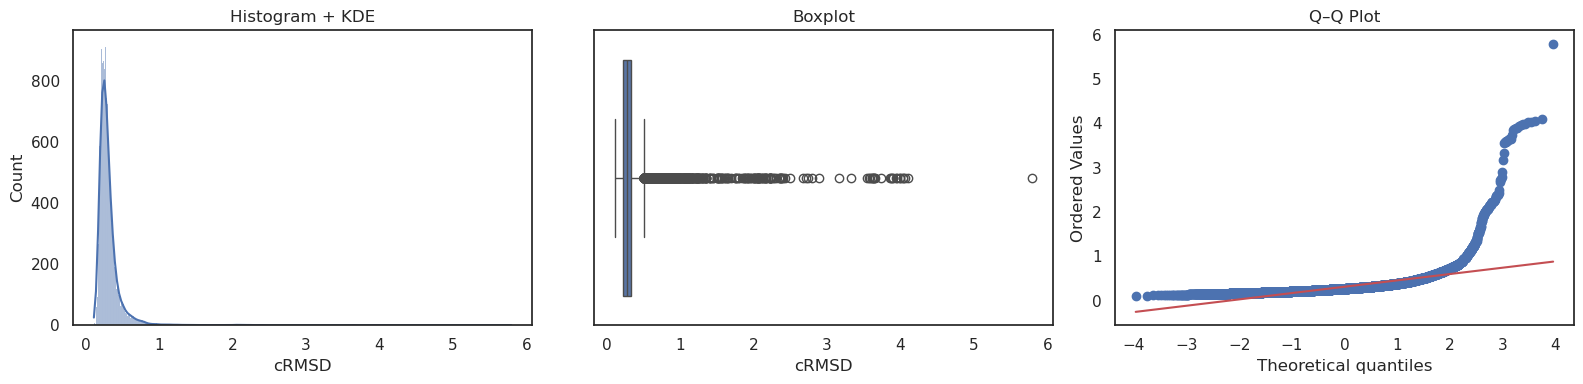

Skewness = 9.065
严重偏态
Normaltest p-value = 0
拒绝正态分布假设


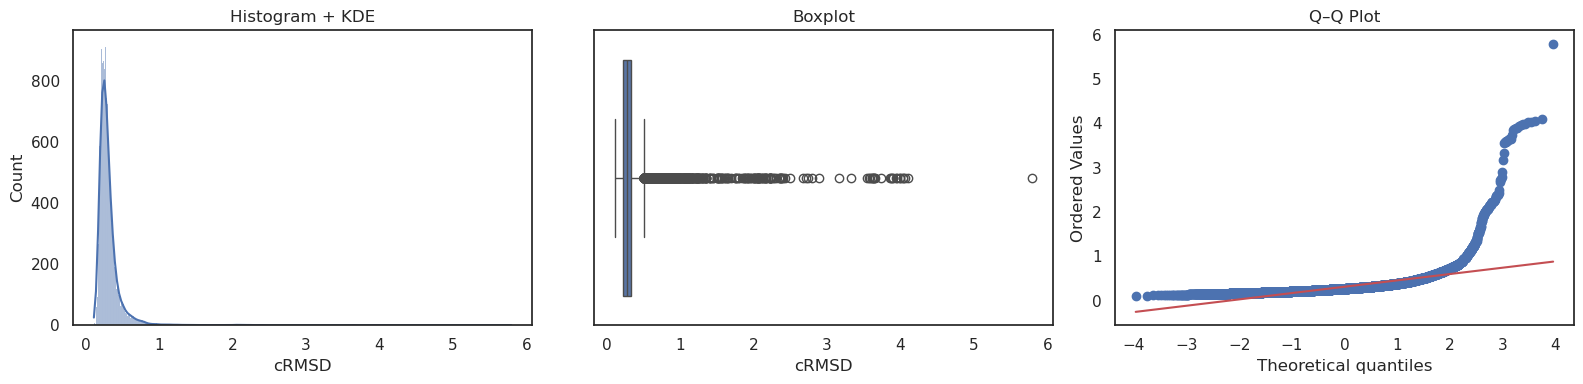

Skewness = 9.065
严重偏态
Normaltest p-value = 0
拒绝正态分布假设


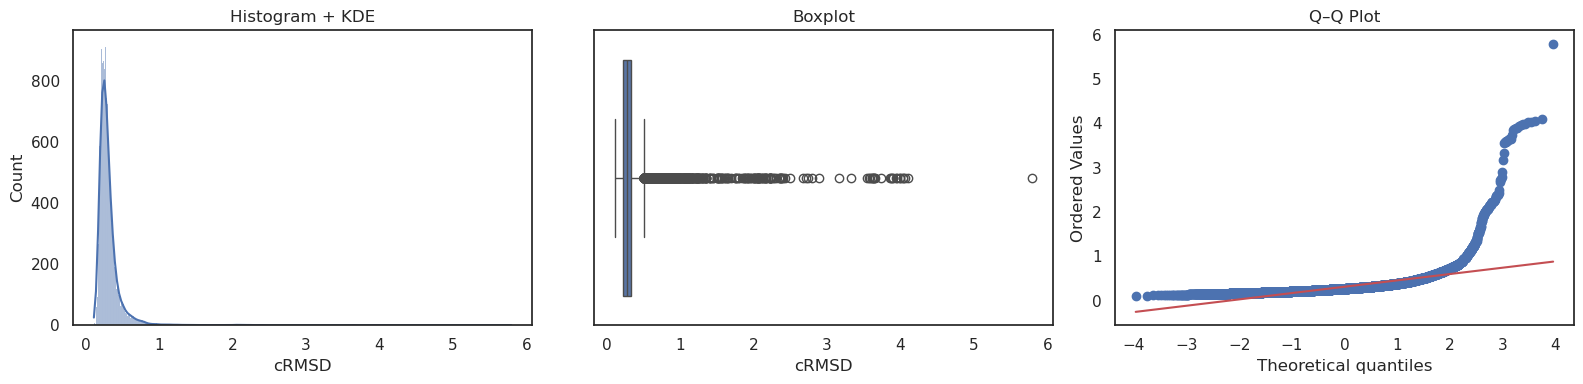

Skewness = 9.065
严重偏态
Normaltest p-value = 0
拒绝正态分布假设


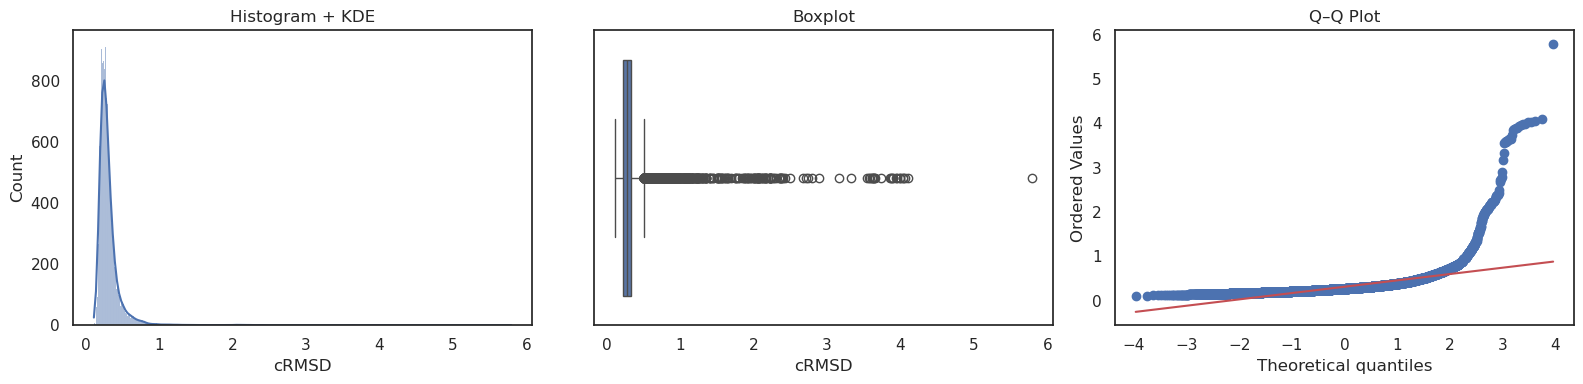

Skewness = 9.065
严重偏态
Normaltest p-value = 0
拒绝正态分布假设


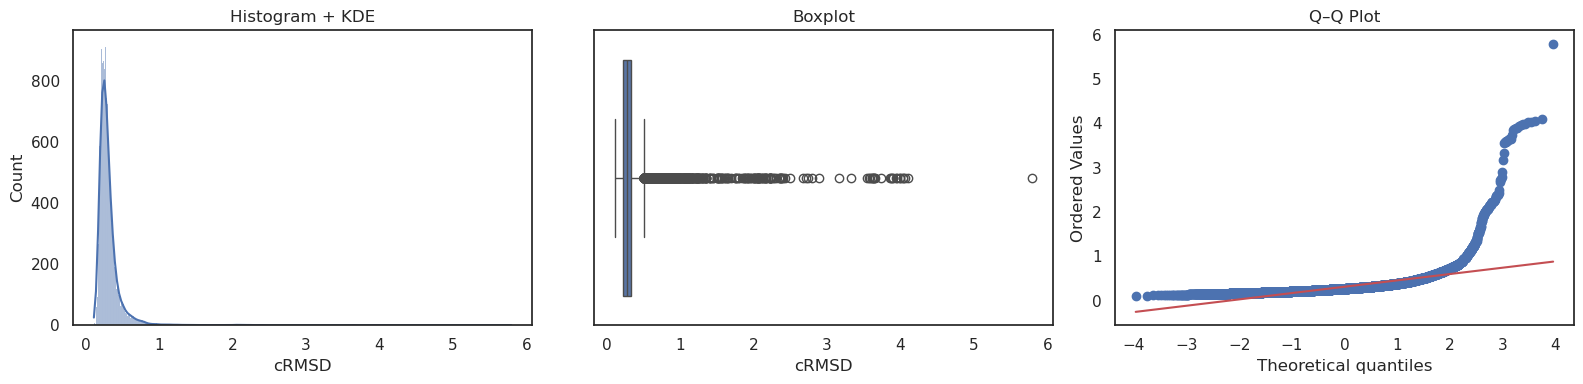

Skewness = 9.065
严重偏态
Normaltest p-value = 0
拒绝正态分布假设


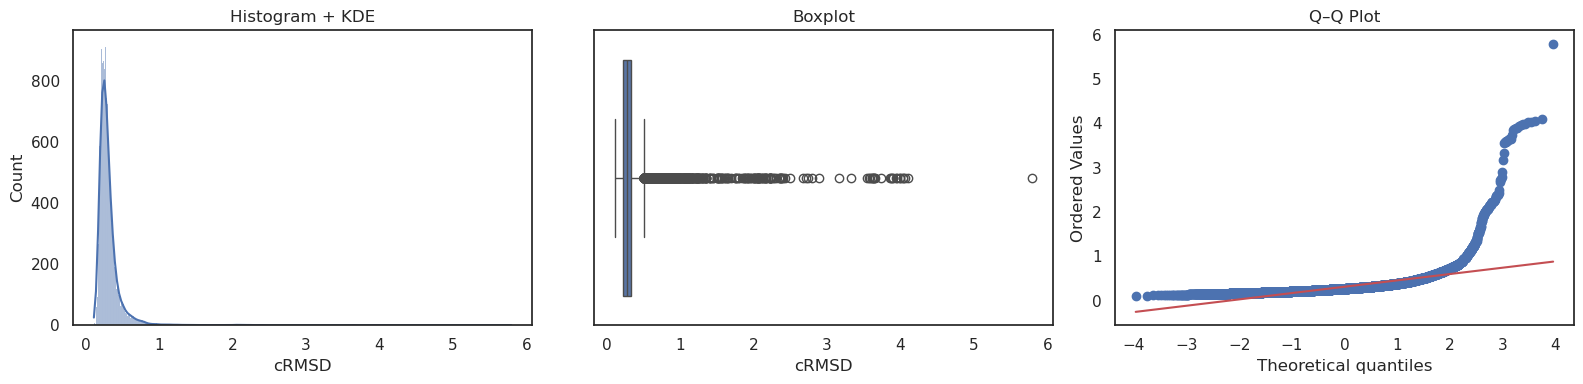

Skewness = 9.065
严重偏态
Normaltest p-value = 0
拒绝正态分布假设


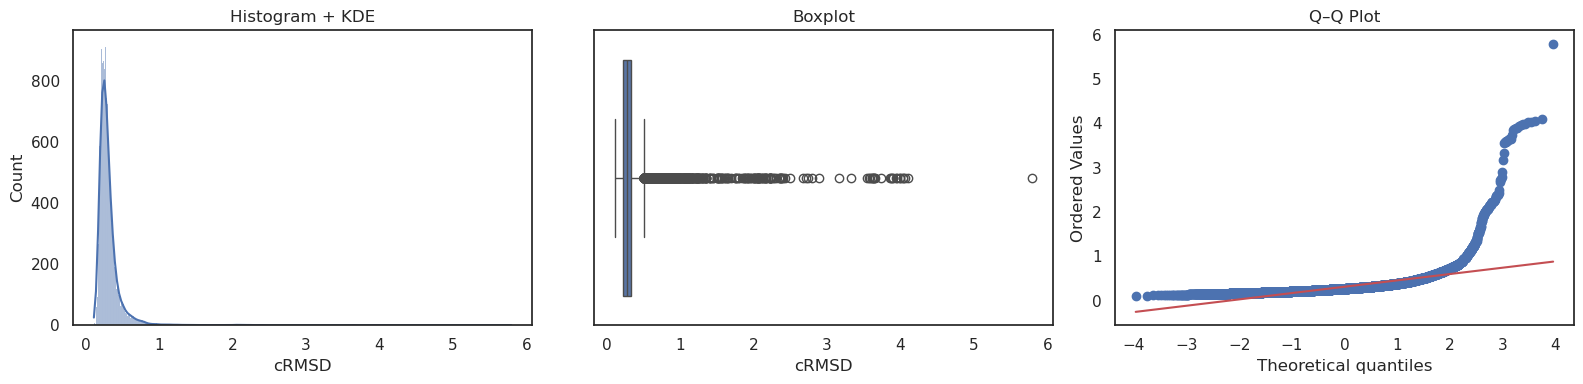

Skewness = 9.065
严重偏态
Normaltest p-value = 0
拒绝正态分布假设


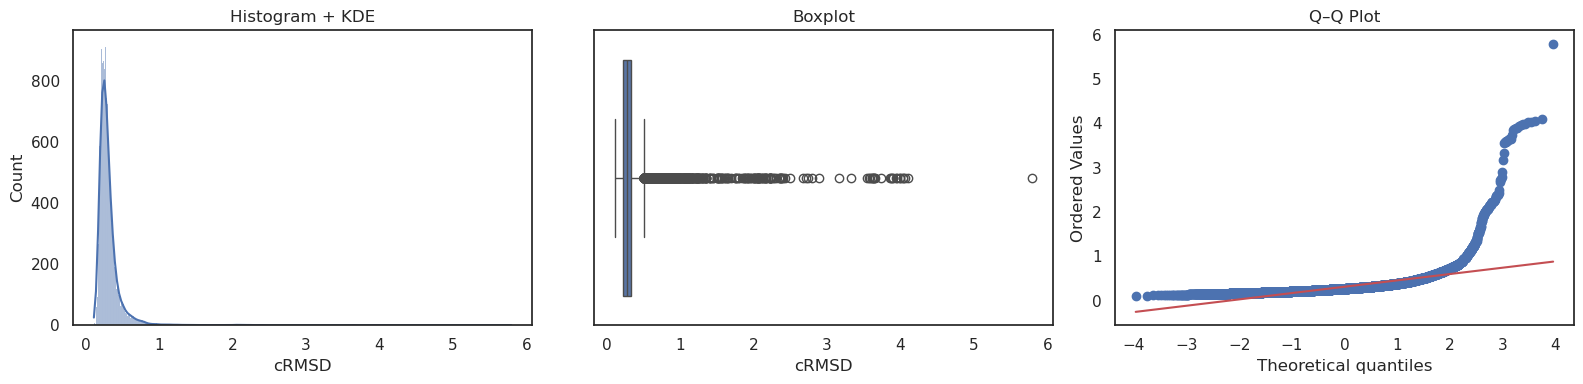

Skewness = 9.065
严重偏态
Normaltest p-value = 0
拒绝正态分布假设


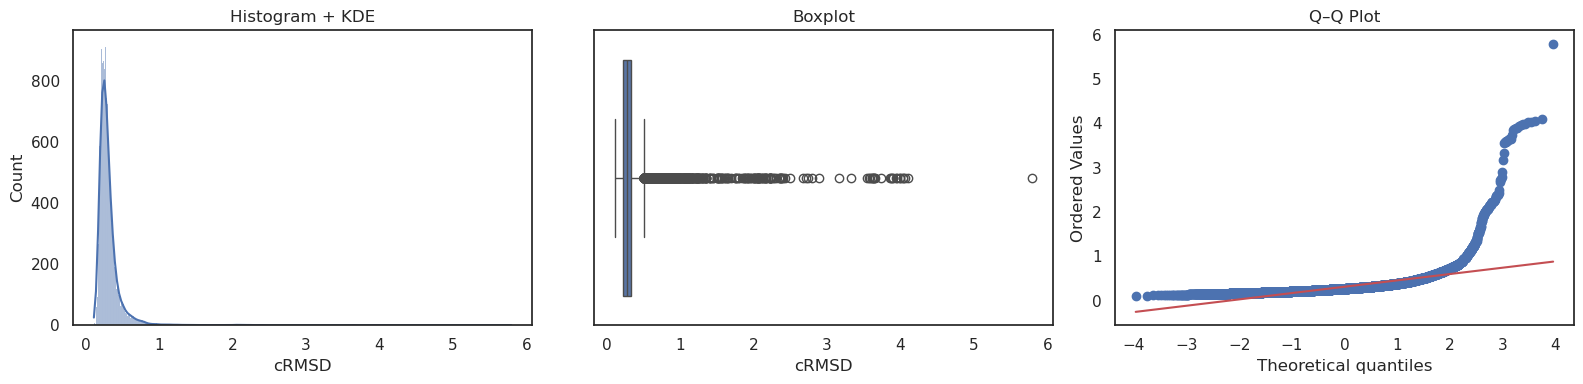

Skewness = 9.065
严重偏态
Normaltest p-value = 0
拒绝正态分布假设


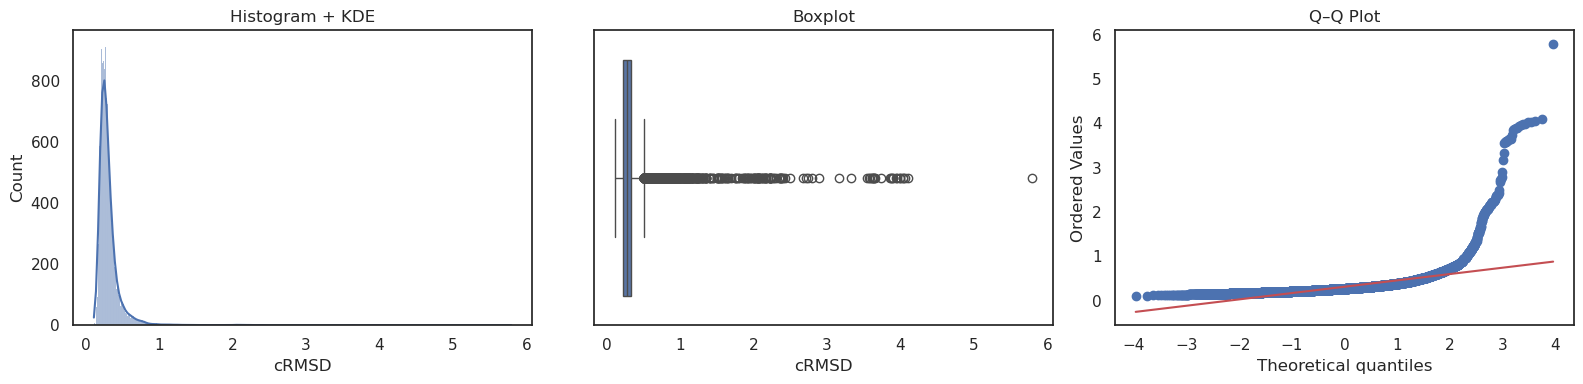

Skewness = 9.065
严重偏态
Normaltest p-value = 0
拒绝正态分布假设


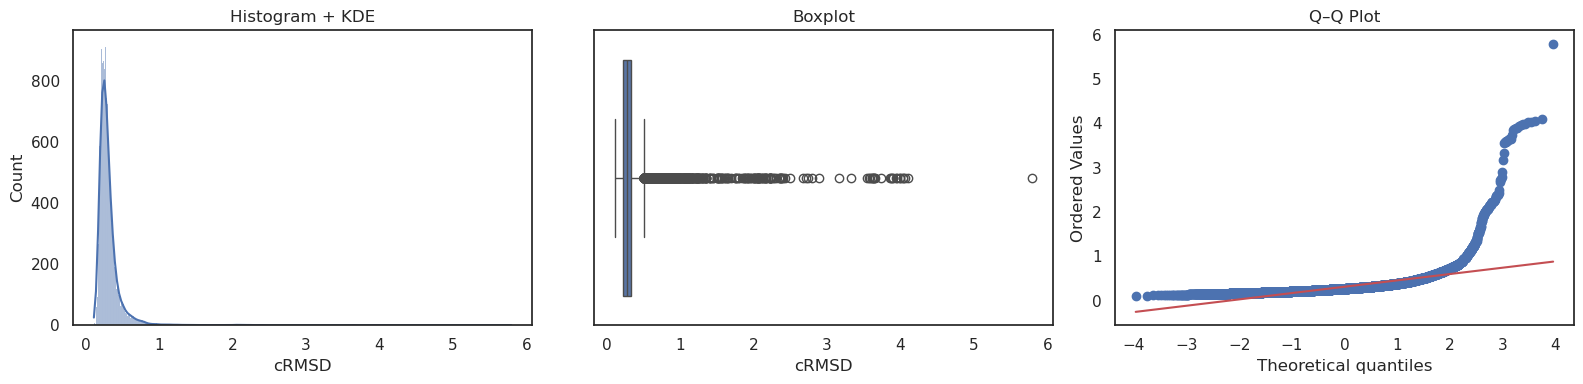

Skewness = 9.065
严重偏态
Normaltest p-value = 0
拒绝正态分布假设


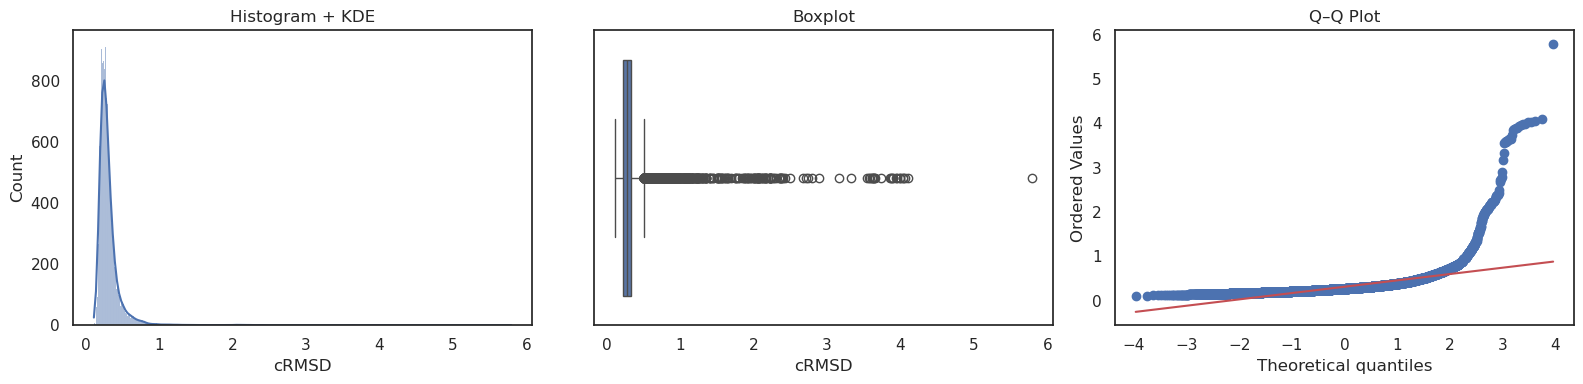

Skewness = 9.065
严重偏态
Normaltest p-value = 0
拒绝正态分布假设


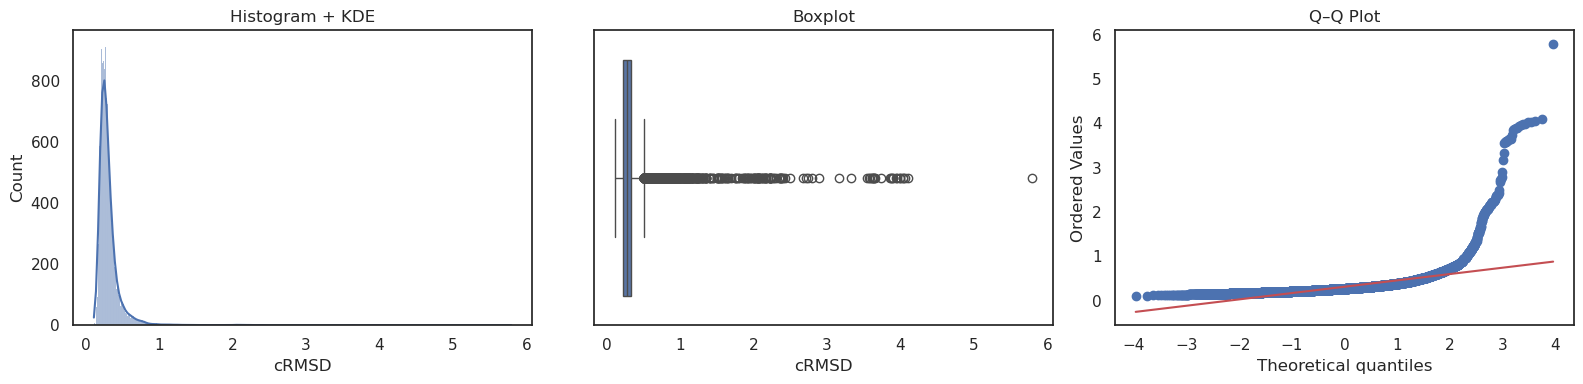

Skewness = 9.065
严重偏态
Normaltest p-value = 0
拒绝正态分布假设


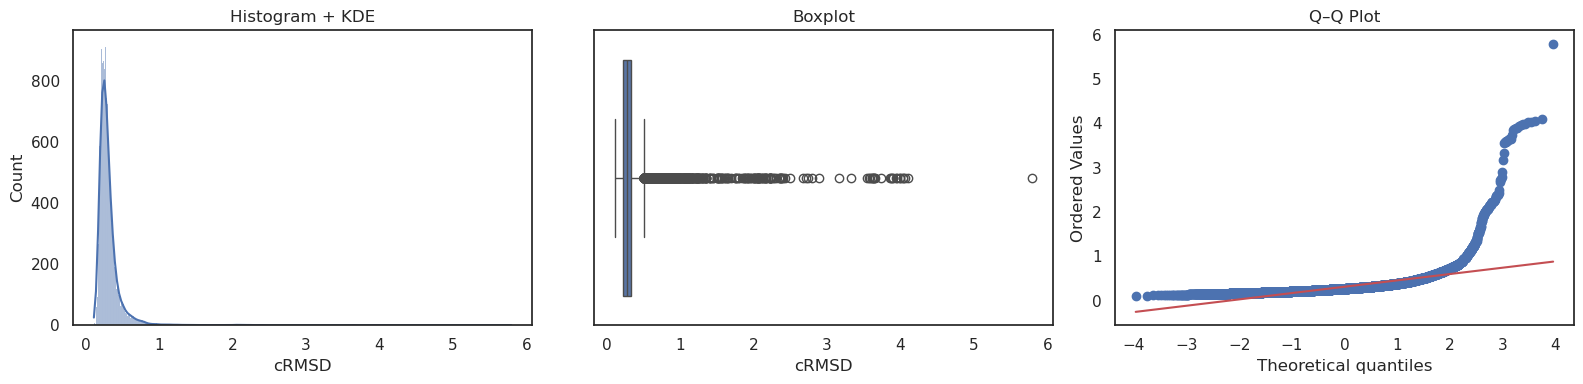

Skewness = 9.065
严重偏态
Normaltest p-value = 0
拒绝正态分布假设


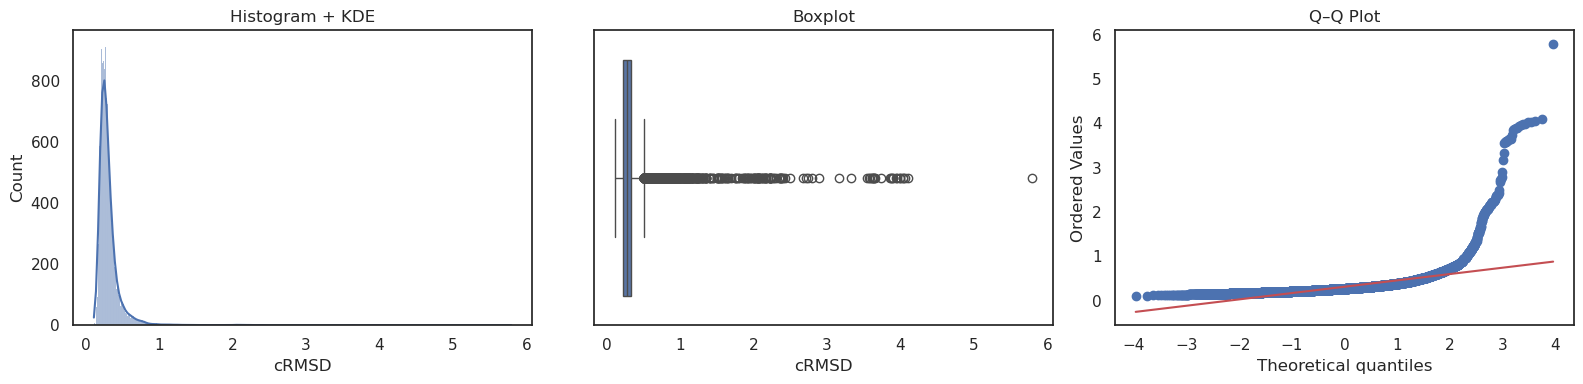

Skewness = 9.065
严重偏态
Normaltest p-value = 0
拒绝正态分布假设


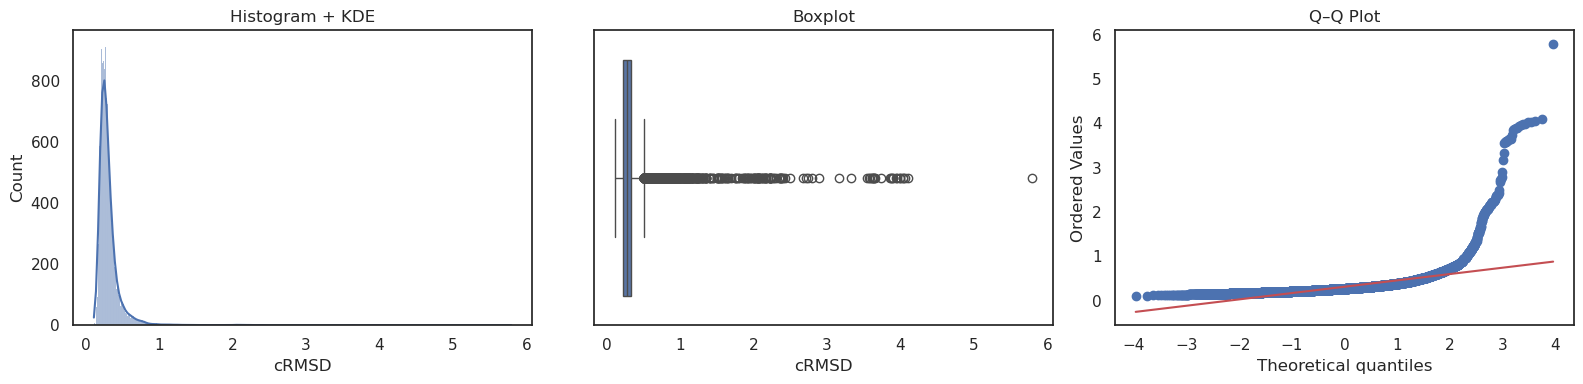

In [13]:
import pandas as pd
from scipy.stats import skew, normaltest
import seaborn as sns, matplotlib.pyplot as plt
import scipy.stats as stats

for stage in stage_list:
    for region in region_list:
        for embe in embe_list:
            col_name = f'{stage}_euclidean_{region}_{embe}_norm'
            col = connector_df[col_name]

            col = connector_df['cRMSD']

            # 1. 计算偏度
            sk = skew(col)
            print(f"Skewness = {sk:.3f}")
            if abs(sk) >= 1:
                print("严重偏态")
            elif abs(sk) >= 0.5:
                print("中度偏态")
            else:
                print("基本对称")

            # 2. 正态性检验
            stat, p = normaltest(col)
            print(f"Normaltest p-value = {p:.3g}")
            if p < 0.05:
                print("拒绝正态分布假设")

            # 3. 可视化
            fig, axes = plt.subplots(1, 3, figsize=(16,4))
            sns.histplot(col, kde=True, ax=axes[0])
            axes[0].set_title("Histogram + KDE")

            sns.boxplot(x=col, ax=axes[1])
            axes[1].set_title("Boxplot")

            stats.probplot(col, dist="norm", plot=axes[2])
            axes[2].set_title("Q–Q Plot")
            plt.tight_layout()
            plt.show()


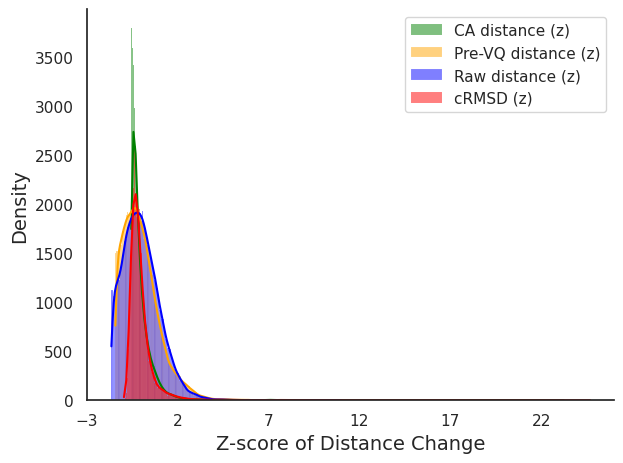

In [13]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 要标准化并绘图的列名
cols = [
    'cRMSD',
    'change_euclidean_all_raw_embeddings',
    'change_euclidean_all_pre_q_embeddings',
    'change_euclidean_all_ca_distance'
]

# 计算 Z-score：(x - mean) / std
z_cols = {}
for col in cols:
    series = connector_df[col].dropna()
    mean = series.mean()
    std  = series.std(ddof=1)
    z_cols[col] = (connector_df[col] - mean) / std

# 绘图
sns.histplot(z_cols[cols[3]], kde=True, label='CA distance (z)', color='green')
sns.histplot(z_cols[cols[2]], kde=True, label='Pre-VQ distance (z)', color='orange')
sns.histplot(z_cols[cols[1]], kde=True, label='Raw distance (z)', color='blue')
sns.histplot(z_cols[cols[0]], kde=True, label='cRMSD (z)', color='red')

plt.legend()
plt.xlabel('Z-score of Distance Change', fontsize=14)
plt.ylabel('Density',              fontsize=14)

# 设置 x 轴刻度间隔为 0.5
xmin, xmax = plt.xlim()
plt.xticks(np.arange(np.floor(xmin), np.ceil(xmax) + 0.5, 5))
plt.xlim(left=np.floor(xmin))

# 去除上、右边框
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()


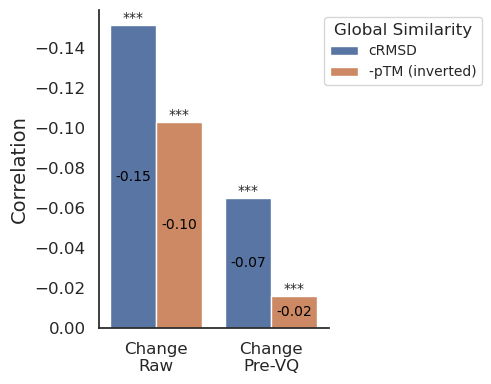

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.container import BarContainer

# 1. 构造汇总结果，pTM 取反
labels = ['change_euclidean_all_raw_embeddings', 'change_euclidean_all_pre_q_embeddings']
targets = ['cRMSD', 'pTM']

rows = []
for lab in labels:
    for tgt in targets:
        corr, pval = spearmanr(connector_df[lab], connector_df[tgt])
        # 对 pTM 取反
        if tgt == 'pTM':
            corr = -corr
        rows.append({
            'label': lab,
            'correlation': corr,
            'p_value':    pval,
            'source':     tgt
        })
res_df = pd.DataFrame(rows)

# 2. 可读 xticks
xticks = ['Change\nRaw', 'Change\nPre-VQ']

# 3. 画图
sns.set(style="white")
fig, ax = plt.subplots(figsize=(5, 4))

palette = {
    'cRMSD': sns.color_palette("deep")[0],
    'pTM':   sns.color_palette("deep")[1]
}

sns.barplot(
    data=res_df,
    x='label', y='correlation',
    hue='source',
    palette=palette,
    dodge=True,
    ax=ax
)

# 4. 设置 x 轴
ax.set_xticks(range(len(xticks)))
ax.set_xticklabels(xticks, rotation=0, ha='center', fontsize=12)

# 5. 贴 r 值
for container in ax.containers:
    if isinstance(container, BarContainer):
        heights = [patch.get_height() for patch in container]
        labels  = [f"{h:.2f}" for h in heights]
        ax.bar_label(
            container,
            labels=labels,
            label_type='center',   # ← 中心贴
            padding=0,             # 贴得更紧凑
            fontsize=10,
            color='black'          # 也可以选个对比色，比如白色
        )

# 6. p-value 星号
def p_to_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

for bar, p in zip(ax.patches, res_df['p_value']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        p_to_stars(p),
        ha='center', va='bottom',
        fontsize=10
    )

# 7. 美化 & 注释 pTM 已取负
ax.set_xlabel('')
ax.set_ylabel('Correlation', fontsize=14)
ax.tick_params(axis='y', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 修改图例标签：将 'pTM' 显示为 '-pTM'
leg = ax.legend(title='Global Similarity', loc='upper left', bbox_to_anchor=(0.95, 1), fontsize=10)
for text in leg.get_texts():
    if text.get_text() == 'pTM':
        text.set_text('-pTM (inverted)')
leg.get_title().set_text('Global Similarity')

ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [15]:
def p_to_stars(p):
    if p <= 0.001:
        return '***'
    elif p <= 0.01:
        return '**'
    elif p <= 0.05:
        return '*'
    else:
        return 'ns'   # 或者空字符串 ''

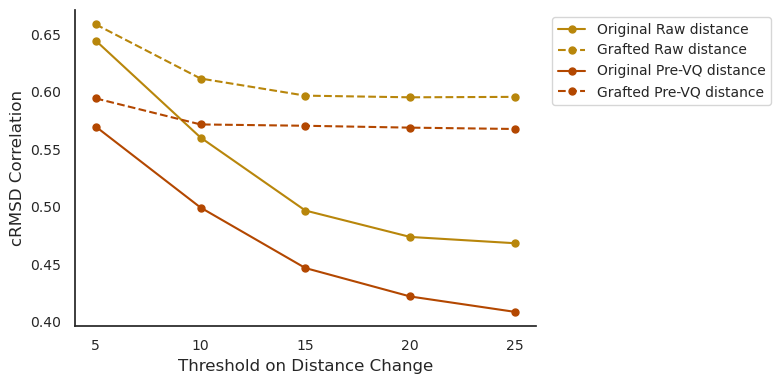

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 要循环的 embedding 类型及配色
embes = [
    ('raw_embeddings',   '#B8860B'),
    ('pre_q_embeddings', '#B34700'),
    # ('ca_distance',      '#1B5E67'),
]

# 固定 thresholds：1.0, 1.25, …, 2.75, 3.0
# thresholds = np.arange(0.5, 3.01, 0.1)
# thresholds = np.arange(5, 25, 1)
thresholds = np.arange(5, 30, 5)

# 初始化画布
plt.figure(figsize=(8, 4))
ax = plt.gca()

for embe, color in embes:
    change_col = f'change_euclidean_all_{embe}'
    orig_col   = f'original_euclidean_all_{embe}_norm'
    graf_col   = f'grafted_euclidean_all_{embe}_norm'
    
    corr_orig, p_orig = [], []
    corr_graf, p_graf = [], []
    
    for th in thresholds:
        df_filt = connector_df[connector_df[change_col] <= th]
        orig_value = df_filt[orig_col]
        graf_value = df_filt[graf_col]
        
        # r_orig, pval_orig = pearsonr(orig_value, df_filt['cRMSD'])
        # r_graf, pval_graf = pearsonr(graf_value, df_filt['cRMSD'])

        r_orig, pval_orig = spearmanr(orig_value, df_filt['cRMSD'])
        r_graf, pval_graf = spearmanr(graf_value, df_filt['cRMSD'])
        
        corr_orig.append(r_orig); p_orig.append(pval_orig)
        corr_graf.append(r_graf); p_graf.append(pval_graf)
    
    # 绘制 corr_orig（实线）
    ax.plot(thresholds, corr_orig,
            marker='o', linestyle='-',
            color=color,
            markersize=5,
            label=f"{embe} → Original")
    # # 标注显著性
    # for x, y, p in zip(thresholds, corr_orig, p_orig):
    #     sig = p_to_stars(p)
    #     if sig:
    #         ax.text(x, y + 0.001, sig,
    #                 ha='center', va='bottom',
    #                 fontsize=8, color=color)
    
    # 绘制 corr_graf（虚线）
    ax.plot(thresholds, corr_graf,
            marker='o', linestyle='--',
            color=color,
            markersize=5,
            label=f"{embe} → Grafted")
    # # 标注显著性
    # for x, y, p in zip(thresholds, corr_graf, p_graf):
    #     sig = p_to_stars(p)
    #     if sig:
    #         ax.text(x, y + 0.001, sig,
    #                 ha='center', va='bottom',
    #                 fontsize=8, color=color)

# 移除背景网格
ax.grid(False)

# 坐标与样式
ax.set_xlabel('Threshold on Distance Change', fontsize=12)
ax.set_ylabel('cRMSD Correlation', fontsize=12)
ax.set_xticks(thresholds)
ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 构造自定义 legend，仅显示统计值
legend_entries = [
    "Original Raw distance",
    "Grafted Raw distance",
    "Original Pre-VQ distance",
    "Grafted Pre-VQ distance",
    "Original CA distance",
    "Grafted CA distance"
]
# ax.legend(legend_entries, loc='best', fontsize=10, frameon=False)
ax.legend(legend_entries, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()


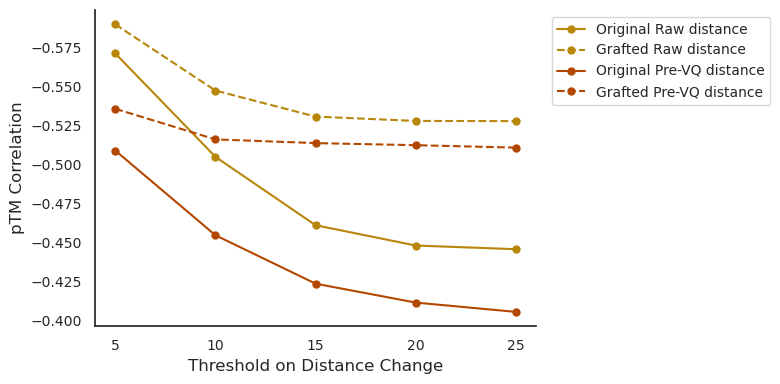

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 要循环的 embedding 类型及配色
embes = [
    ('raw_embeddings',   '#B8860B'),
    ('pre_q_embeddings', '#B34700'),
    # ('ca_distance',      '#1B5E67'),
]

# 固定 thresholds：1.0, 1.25, …, 2.75, 3.0
# thresholds = np.arange(0.5, 3.01, 0.1)
# thresholds = np.arange(5, 25, 1)
thresholds = np.arange(5, 30, 5)

# 初始化画布
plt.figure(figsize=(8, 4))
ax = plt.gca()

for embe, color in embes:
    change_col = f'change_euclidean_all_{embe}'
    orig_col   = f'original_euclidean_all_{embe}_norm'
    graf_col   = f'grafted_euclidean_all_{embe}_norm'
    
    corr_orig, p_orig = [], []
    corr_graf, p_graf = [], []
    
    for th in thresholds:
        df_filt = connector_df[connector_df[change_col] <= th]
        orig_value = df_filt[orig_col]
        graf_value = df_filt[graf_col]
        
        # r_orig, pval_orig = pearsonr(orig_value, df_filt['pTM'])
        # r_graf, pval_graf = pearsonr(graf_value, df_filt['pTM'])

        r_orig, pval_orig = spearmanr(orig_value, df_filt['pTM'])
        r_graf, pval_graf = spearmanr(graf_value, df_filt['pTM'])
        
        corr_orig.append(r_orig); p_orig.append(pval_orig)
        corr_graf.append(r_graf); p_graf.append(pval_graf)
    
    # 绘制 corr_orig（实线）
    ax.plot(thresholds, corr_orig,
            marker='o', linestyle='-',
            color=color,
            markersize=5,
            label=f"{embe} → Original")
    # # 标注显著性
    # for x, y, p in zip(thresholds, corr_orig, p_orig):
    #     sig = p_to_stars(p)
    #     if sig:
    #         ax.text(x, y + 0.001, sig,
    #                 ha='center', va='bottom',
    #                 fontsize=8, color=color)
    
    # 绘制 corr_graf（虚线）
    ax.plot(thresholds, corr_graf,
            marker='o', linestyle='--',
            color=color,
            markersize=5,
            label=f"{embe} → Grafted")
    # # 标注显著性
    # for x, y, p in zip(thresholds, corr_graf, p_graf):
    #     sig = p_to_stars(p)
    #     if sig:
    #         ax.text(x, y + 0.001, sig,
    #                 ha='center', va='bottom',
    #                 fontsize=8, color=color)

# 移除背景网格
ax.grid(False)

# 坐标与样式
ax.set_xlabel('Threshold on Distance Change', fontsize=12)
ax.set_ylabel('pTM Correlation', fontsize=12)
ax.set_xticks(thresholds, )
ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 构造自定义 legend，仅显示统计值
legend_entries = [
    "Original Raw distance",
    "Grafted Raw distance",
    "Original Pre-VQ distance",
    "Grafted Pre-VQ distance",
    "Original CA distance",
    "Grafted CA distance"
]
# ax.legend(legend_entries, loc='best', fontsize=10, frameon=False)
ax.legend(legend_entries, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

ax.invert_yaxis()
plt.xticks(rotation=0, ha='center')

plt.tight_layout()
plt.show()


In [19]:
from scipy.stats import pearsonr

# region_list = ['all']
embe_list = ['raw_embeddings', 'pre_q_embeddings', 'ca_distance']

def collect_results_pearson(df, stage, source_label, region_list, target='cRMSD'):
    rows = []
    for region in region_list:
        for embe in embe_list:
            col = f'{stage}_euclidean_{region}_{embe}_norm'
            r, p = pearsonr(df[col], df[target])
            rows.append({
                'region': region,
                'embedding': embe,
                'label': f'{region}_{embe}',
                # 'label': f'{embe}',
                'correlation': r,
                'p_value': p,
                'source': source_label
            })
    return pd.DataFrame(rows)

def collect_results_spearman(df, stage, source_label, region_list, target='cRMSD'):
    rows = []
    for region in region_list:
        for embe in embe_list:
            col = f'{stage}_euclidean_{region}_{embe}_norm'
            # 用 Spearman 相关替代 Pearson
            rho, pval = spearmanr(df[col], df[target])
            rows.append({
                'region':      region,
                'embedding':   embe,
                'label':       f'{region}_{embe}',
                'correlation': rho,
                'p_value':     pval,
                'source':      source_label
            })
    return pd.DataFrame(rows)


In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_connector_correlation(res_df, target, xticks=None, figsize=(8, 5), x_rotation=None, invert=False, fontsize=14, legend_loc=0.8):
    # 绘图
    sns.set(style="white")
    fig, ax = plt.subplots(figsize=figsize)

    # 1) 画柱状图
    palette = {
        'Original Connector': sns.color_palette("deep")[0],
        'Grafted Connector':  sns.color_palette("deep")[1]
    }
    ax = sns.barplot(
        data=res_df,
        x='label', y='correlation',
        hue='source',
        palette=palette,
        dodge=True,
        ax=ax
    )

    # 2) 设置 x 轴刻度和标签
    if xticks:
        ax.set_xticks(range(len(xticks)))
        ax.set_xticklabels(
            xticks,
            fontsize=fontsize
        )
    
    if x_rotation:
        plt.xticks(rotation=x_rotation, ha='center')

    # 3) 给每个柱子内部加上 r 值标签
    def format_r(val):
        return f"{val:.2f}"

    # 把数据按 source 分开，保证顺序和容器（containers）一致
    r_orig  = res_df[res_df['source']=='Original Connector']['correlation'].values
    r_graft = res_df[res_df['source']=='Grafted Connector']['correlation'].values

    # ax.containers 是两个条形集合（Original, Grafted）
    for container, r_vals in zip(ax.containers, [r_orig, r_graft]):
        labels = [format_r(r_) for r_ in r_vals]
        ax.bar_label(
            container,
            labels=labels,
            label_type='center',
            fontsize=fontsize-2
        )

    # 4) p-value 星号（如果还想保留）
    for bar, p in zip(ax.patches, res_df['p_value']):
        stars = p_to_stars(p)  # 你的函数
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            stars,
            ha='center', va='bottom',
            fontsize=12
        )

    # 5) 美化其余部分
    ax.set_xlabel('')
    ax.set_ylabel(f'{target} Correlation', fontsize=fontsize+2)
    ax.tick_params(axis='y', labelsize=fontsize)

    # 隐藏上右边框
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)

    # 图例放到右侧外面
    ax.legend(
        title='Connector source',
        loc='upper left',
        bbox_to_anchor=(legend_loc, 1),
        borderaxespad=0,
        title_fontsize=fontsize,
        fontsize=fontsize-2
    )

    # 翻转 y 轴
    if invert:
        ax.invert_yaxis()

    plt.tight_layout()
    
    return plt

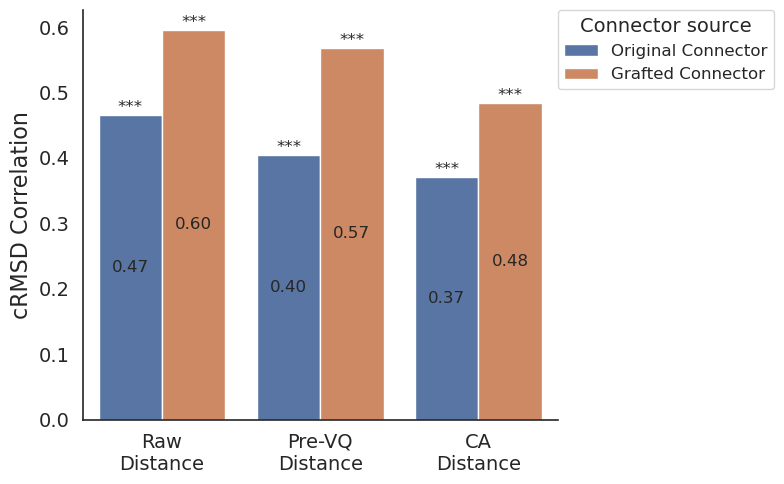

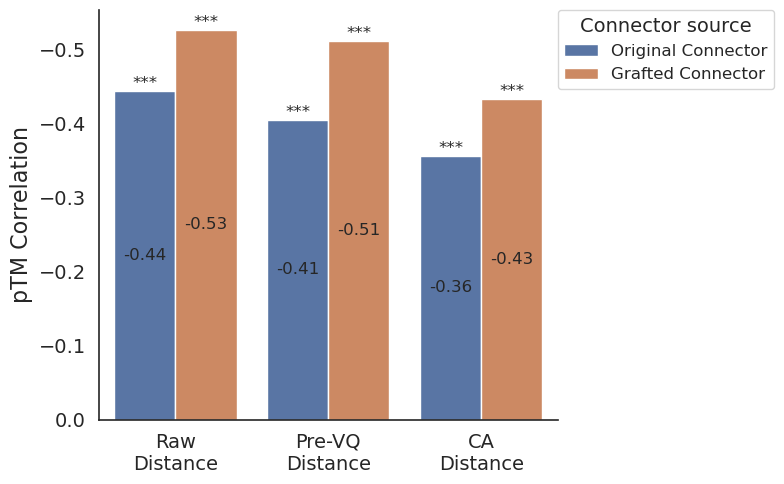

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt


# 汇总两张表的数据
# res_conn = collect_results(connector_df, stage='original', source_label='Original Connector', target='cRMSD')
# res_algn = collect_results(connector_df, stage='grafted', source_label='Grafted Connector', target='cRMSD')

xticks=['Raw\nDistance', 'Pre-VQ\nDistance', 'CA\nDistance']
legend_loc = 1

crmsd_res_conn = collect_results_spearman(connector_df, stage='original', source_label='Original Connector', region_list = ['all'], target='cRMSD')
crmsd_res_algn = collect_results_spearman(connector_df, stage='grafted', source_label='Grafted Connector', region_list = ['all'], target='cRMSD')
crmsd_res_df   = pd.concat([crmsd_res_conn, crmsd_res_algn], ignore_index=True)

crmsd_plt = plot_connector_correlation(crmsd_res_df, target='cRMSD', xticks=xticks, figsize=(8, 5), legend_loc=legend_loc)
crmsd_plt.show()

ptm_res_conn = collect_results_spearman(connector_df, stage='original', source_label='Original Connector', region_list = ['all'], target='pTM')
ptm_res_algn = collect_results_spearman(connector_df, stage='grafted', source_label='Grafted Connector', region_list = ['all'], target='pTM')
ptm_res_df   = pd.concat([ptm_res_conn, ptm_res_algn], ignore_index=True)

ptm_plt = plot_connector_correlation(ptm_res_df, target='pTM', xticks=xticks, figsize=(8, 5), invert=True, legend_loc=legend_loc)
ptm_plt.show()




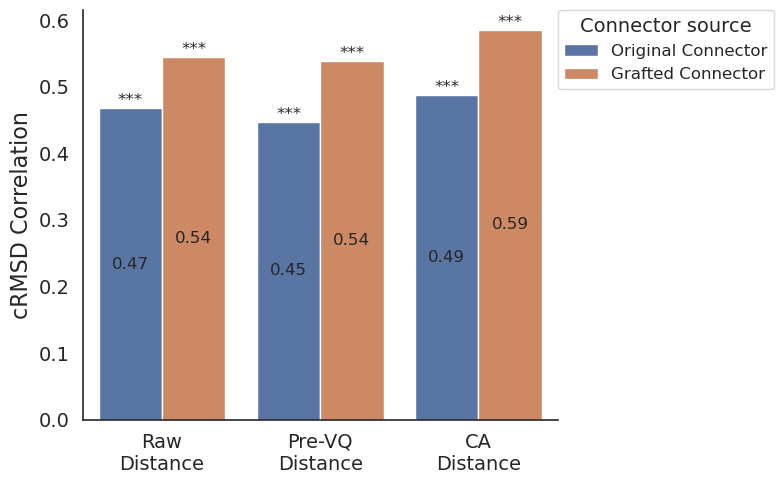

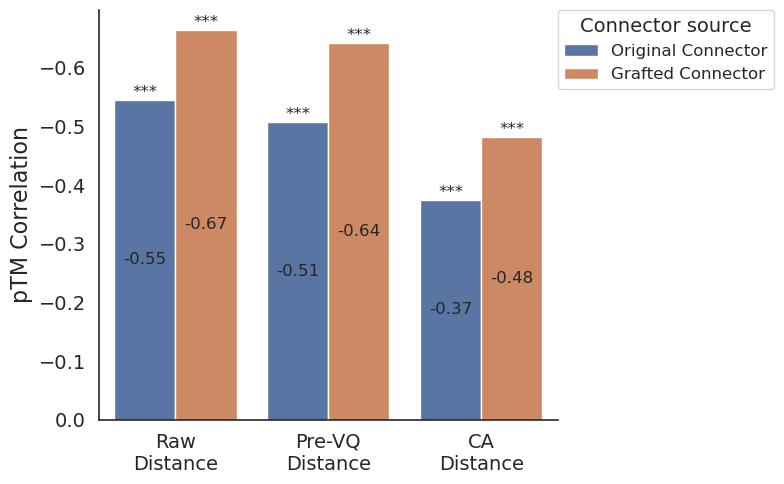

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt


# 汇总两张表的数据
# res_conn = collect_results(connector_df, stage='original', source_label='Original Connector', target='cRMSD')
# res_algn = collect_results(connector_df, stage='grafted', source_label='Grafted Connector', target='cRMSD')

xticks=['Raw\nDistance', 'Pre-VQ\nDistance', 'CA\nDistance']
legend_loc = 1

crmsd_res_conn = collect_results_pearson(connector_df, stage='original', source_label='Original Connector', region_list = ['all'], target='cRMSD')
crmsd_res_algn = collect_results_pearson(connector_df, stage='grafted', source_label='Grafted Connector', region_list = ['all'], target='cRMSD')
crmsd_res_df   = pd.concat([crmsd_res_conn, crmsd_res_algn], ignore_index=True)

crmsd_plt = plot_connector_correlation(crmsd_res_df, target='cRMSD', xticks=xticks, figsize=(8, 5), legend_loc=legend_loc)
crmsd_plt.show()

ptm_res_conn = collect_results_pearson(connector_df, stage='original', source_label='Original Connector', region_list = ['all'], target='pTM')
ptm_res_algn = collect_results_pearson(connector_df, stage='grafted', source_label='Grafted Connector', region_list = ['all'], target='pTM')
ptm_res_df   = pd.concat([ptm_res_conn, ptm_res_algn], ignore_index=True)

ptm_plt = plot_connector_correlation(ptm_res_df, target='pTM', xticks=xticks, figsize=(8, 5), invert=True, legend_loc=legend_loc)
ptm_plt.show()




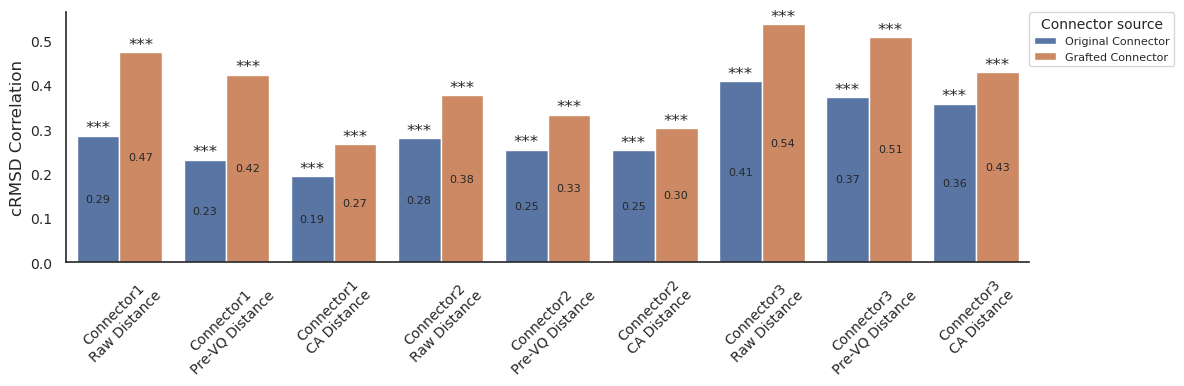

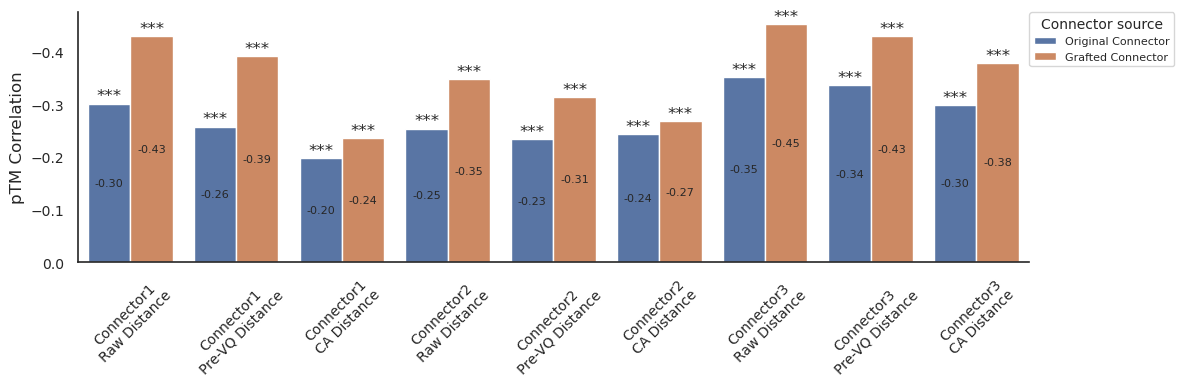

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt


# 汇总两张表的数据
# res_conn = collect_results(connector_df, stage='original', source_label='Original Connector', target='cRMSD')
# res_algn = collect_results(connector_df, stage='grafted', source_label='Grafted Connector', target='cRMSD')

xticks = [f"{region}\n{embe}"
            for region in ['Connector1', 'Connector2', 'Connector3']
            for embe   in ['Raw Distance', 'Pre-VQ Distance', 'CA Distance']]

fontsize = 10
legend_loc = 1

crmsd_res_conn_all = collect_results_spearman(connector_df, stage='original', source_label='Original Connector', region_list = ['connector1', 'connector2', 'connector3'], target='cRMSD')
crmsd_res_algn_all = collect_results_spearman(connector_df, stage='grafted', source_label='Grafted Connector', region_list = ['connector1', 'connector2', 'connector3'], target='cRMSD')
crmsd_res_df_all = pd.concat([crmsd_res_conn_all, crmsd_res_algn_all], ignore_index=True)

crmsd_plt_all = plot_connector_correlation(crmsd_res_df_all, target='cRMSD', xticks=xticks, x_rotation=45, figsize=(12, 4), fontsize=fontsize, legend_loc=legend_loc)
crmsd_plt_all.show()

ptm_res_conn_all = collect_results_spearman(connector_df, stage='original', source_label='Original Connector', region_list = ['connector1', 'connector2', 'connector3'], target='pTM')
ptm_res_algn_all = collect_results_spearman(connector_df, stage='grafted', source_label='Grafted Connector', region_list = ['connector1', 'connector2', 'connector3'], target='pTM')
ptm_res_df_all = pd.concat([ptm_res_conn_all, ptm_res_algn_all], ignore_index=True)

ptm_plt_all = plot_connector_correlation(ptm_res_df_all, target='pTM', xticks=xticks, x_rotation=45, figsize=(12, 4), invert=True, fontsize=fontsize, legend_loc=legend_loc)
ptm_plt_all.show()



## Test

In [149]:
def norm_calc_change(orig_value, graf_value, length=12):
    norm_orig_value = orig_value/ np.sqrt(length)
    norm_graf_value = graf_value/ np.sqrt(length)
    change = abs(norm_orig_value - norm_graf_value)
    return norm_orig_value.round(3), norm_graf_value.round(3), change.round(3)

In [152]:
orig_value_8tao = 77.075
graf_value_8tao = 40.475
print(norm_calc_change(orig_value_8tao, graf_value_8tao, length=12))

orig_value_5imm = 66.109
graf_value_5imm = 44.006
print(norm_calc_change(orig_value_5imm, graf_value_5imm, length=12))

orig_value_1zmy = 85.709
graf_value_1zmy = 50.850
print(norm_calc_change(orig_value_1zmy, graf_value_1zmy, length=12))

orig_value_3k1k = 83.480
graf_value_3k1k = 47.497
print(norm_calc_change(orig_value_3k1k, graf_value_3k1k, length=12))

(22.25, 11.684, 10.566)
(19.084, 12.703, 6.381)
(24.742, 14.679, 10.063)
(24.099, 13.711, 10.387)


In [151]:
orig_value_3k1k = 83.480
graf_value_3k1k = 38.150
print(norm_calc_change(orig_value_3k1k, graf_value_3k1k, length=12))

(24.099, 11.013, 13.086)
